ARTI308 - Machine Learning

# Lab 3 Assignment: Exploratory Data Analysis (EDA)

**Dataset:** Superstore Sales (`train.xlsx`)

Each row in the dataset is one product line inside a customer order placed at a US retail superstore. The columns describe the order (ID, order date, ship date, ship mode), the customer (ID, name, segment), the location (country, city, state, postal code, region), the product (ID, category, sub-category, name), and the sales value of that line.

The goal of this notebook is to understand the structure and quality of the data, clean it, and extract insights about products, customers, regions, shipping, and sales over time before a model that predicts `Sales` is built.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load the Dataset

In [2]:
df = pd.read_excel("train.xlsx")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-08-11 00:00:00,2017-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-08-11 00:00:00,2017-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-12-06 00:00:00,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-11-10 00:00:00,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-11-10 00:00:00,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


The first rows show 18 columns mixing identifiers, categorical text, dates, and one numerical target (`Sales`). Two things stand out immediately: `Order Date` and `Ship Date` do not look consistent (some cells appear as full timestamps and others as `dd/mm/yyyy` text), and `Country` seems to hold the same value in every row. Both are checked in the cleaning section.

## 3. Data Structure

### 3.1 Number of rows and columns

In [3]:
print("Shape (rows, columns):", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Shape (rows, columns): (9800, 18)
Number of rows: 9800
Number of columns: 18


The dataset contains 9,800 order lines and 18 columns. It is large enough for meaningful group comparisons but small enough that every plot runs instantly.

### 3.2 Data types

In [4]:
df.dtypes

Row ID             int64
Order ID             str
Order Date        object
Ship Date         object
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object

Only `Row ID`, `Postal Code`, and `Sales` are numeric. `Order Date` and `Ship Date` have the generic `object` type instead of `datetime`, which confirms that pandas could not read them as a single consistent date format. All remaining columns are text.

### 3.3 General information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

## 4. Data Cleaning

### 4.1 Inspect the date columns

Both date columns contain a mix of two kinds of values. The cell below counts how many cells were read by Excel as real dates and how many stayed as plain text.

In [6]:
for col in ["Order Date", "Ship Date"]:
    is_text = df[col].apply(lambda v: isinstance(v, str))
    print(col, "-> parsed as date:", (~is_text).sum(), "| left as text:", is_text.sum())
    print("   text examples:", df.loc[is_text, col].head(3).tolist())
    print("   date examples:", df.loc[~is_text, col].head(3).tolist())

Order Date -> parsed as date: 3959 | left as text: 5841
   text examples: ['15/04/2018', '22/11/2016', '22/11/2016']
   date examples: [datetime.datetime(2017, 8, 11, 0, 0), datetime.datetime(2017, 8, 11, 0, 0), datetime.datetime(2017, 12, 6, 0, 0)]
Ship Date -> parsed as date: 3815 | left as text: 5985
   text examples: ['16/06/2017', '18/10/2016', '18/10/2016']
   date examples: [datetime.datetime(2017, 11, 11, 0, 0), datetime.datetime(2017, 11, 11, 0, 0), datetime.datetime(2017, 10, 12, 0, 0)]


Around 40% of the cells were converted to dates by Excel and 60% were left as text. The text values are clearly in day/month/year order (for example `16/06/2017`, where 16 cannot be a month). Excel only converted the cells whose day was 12 or less, and it read them in month/day order, so those dates have the day and month swapped. For example the first order was read as 11 August 2017 with a ship date of 11 November 2017, which would mean a 92-day delivery for Second Class shipping. Read correctly (8 November to 11 November) it is a 3-day delivery.

The fix therefore has two branches: parse text values with `dayfirst=True`, and swap the month and day of the values Excel already converted.

In [7]:
def fix_date(value):
    if isinstance(value, str):
        return pd.to_datetime(value, dayfirst=True)
    return pd.Timestamp(year=value.year, month=value.day, day=value.month)

df["Order Date"] = df["Order Date"].apply(fix_date)
df["Ship Date"] = df["Ship Date"].apply(fix_date)

df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

To verify the correction, the number of days between order and shipment is calculated. If the dates are right, every value should be small and non-negative, and it should match the shipping mode.

In [8]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

print("Negative shipping days:", (df["Shipping Days"] < 0).sum())
print(df["Shipping Days"].describe().round(2))
print()
print(df.groupby("Ship Mode")["Shipping Days"].mean().round(2))

Negative shipping days: 0
count    9800.00
mean        3.96
std         1.75
min         0.00
25%         3.00
50%         4.00
75%         5.00
max         7.00
Name: Shipping Days, dtype: float64

Ship Mode
First Class       2.18
Same Day          0.04
Second Class      3.25
Standard Class    5.01
Name: Shipping Days, dtype: float64


There are no negative values, all deliveries take between 0 and 7 days, and the average matches the shipping mode exactly (Same Day is about 0 days, First Class about 2, Second Class about 3, Standard Class about 5). This confirms that the dates are now correct. Dates run from January 2015 to December 2018.

### 4.2 Missing values

In [9]:
df.isna().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Shipping Days     0
dtype: int64

In [10]:
df[df["Postal Code"].isna()][["City", "State", "Postal Code"]].drop_duplicates()

,City,State,Postal Code
2234,Burlington,Vermont,NaN


The only missing values are 11 postal codes, all belonging to Burlington, Vermont. The postal code is not needed for the analysis because city, state, and region already describe the location, so instead of dropping 11 valid sales the missing values are filled with the real postal code of Burlington, VT (05401).

In [11]:
df["Postal Code"] = df["Postal Code"].fillna(5401).astype(int)
print("Missing values after cleaning:", df.isna().sum().sum())

Missing values after cleaning: 0


### 4.3 Duplicate rows

In [12]:
print("Number of duplicate rows:", df.duplicated().sum())
print("Duplicate rows ignoring Row ID:", df.drop(columns="Row ID").duplicated().sum())

Number of duplicate rows: 0
Duplicate rows ignoring Row ID: 1


No duplicate order lines exist, even after ignoring the `Row ID` column, so nothing needs to be removed.

### 4.4 Check categorical values

In [13]:
for col in ["Country", "Region", "State", "City", "Segment", "Ship Mode", "Category", "Sub-Category", "Customer ID", "Product ID"]:
    print(f"{col:14s} -> {df[col].nunique()} unique values")

Country        -> 1 unique values
Region         -> 4 unique values
State          -> 49 unique values
City           -> 529 unique values
Segment        -> 3 unique values
Ship Mode      -> 4 unique values
Category       -> 3 unique values
Sub-Category   -> 17 unique values
Customer ID    -> 793 unique values
Product ID     -> 1861 unique values


In [14]:
df["Country"].value_counts()

Country
United States    9800
Name: count, dtype: int64

`Country` contains a single value (United States) for every row, so it carries no information and is dropped. `Row ID` is only a row counter and is dropped as well. The other categorical columns have a sensible number of categories with no spelling variations: 4 regions, 49 states, 3 customer segments, 4 ship modes, 3 categories, and 17 sub-categories.

In [15]:
df = df.drop(columns=["Row ID", "Country"])
df.shape

(9800, 17)

### 4.5 Add derived columns

Helper columns are added for time-based analysis: the order year, the year-month, and the month name for seasonality.

In [16]:
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.to_period("M")
df["Month Name"] = df["Order Date"].dt.month_name()

df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Shipping Days,Order Year,Order Month,Month Name
0,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,3,2017,2017-11,November
1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,2017,2017-11,November
2,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,4,2017,2017-06,June
3,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,7,2016,2016-10,October
4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,7,2016,2016-10,October


## 5. Descriptive Statistics

In [17]:
df[["Sales", "Shipping Days"]].describe().round(2)

,Sales,Shipping Days
count,9800.00,9800.00
mean,230.77,3.96
std,626.65,1.75
min,0.44,0.00
25%,17.25,3.00
50%,54.49,4.00
75%,210.60,5.00
max,22638.48,7.00


`Sales` is extremely skewed: the median order line is about \$54 while the mean is about \$231, and the maximum is over \$22,000. Three quarters of all lines are below \$211. This means a small number of very expensive items pull the average up, which will matter when choosing and evaluating a regression model. Shipping takes 4 days on average.

In [18]:
df[["Order ID", "Ship Mode", "Customer Name", "Segment", "City", "State", "Region", "Product ID", "Category", "Sub-Category"]].describe()

,Order ID,Ship Mode,Customer Name,Segment,City,State,Region,Product ID,Category,Sub-Category
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,4,793,3,529,49,4,1861,3,17
top,CA-2018-100111,Standard Class,William Brown,Consumer,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders
freq,14,5859,35,5101,891,1946,3140,19,5909,1492


The most common values are Standard Class shipping, the Consumer segment, the West region, California, Office Supplies, and the Binders sub-category. There are 793 distinct customers and 1,861 distinct products spread over 4,922 orders, so most customers order more than once and most orders contain about two product lines.

## 6. Univariate Analysis

### 6.1 Distribution of Sales

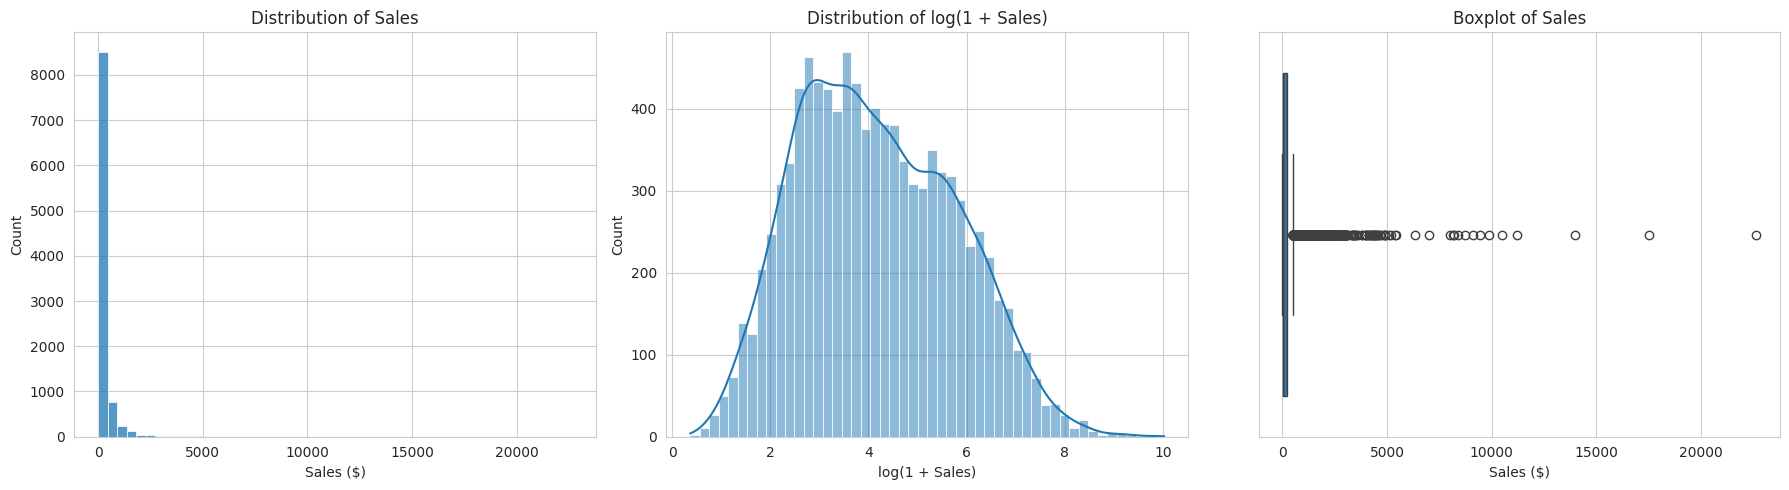

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["Sales"], bins=50, ax=axes[0])
axes[0].set_title("Distribution of Sales")
axes[0].set_xlabel("Sales ($)")

sns.histplot(np.log1p(df["Sales"]), bins=50, kde=True, ax=axes[1])
axes[1].set_title("Distribution of log(1 + Sales)")
axes[1].set_xlabel("log(1 + Sales)")

sns.boxplot(x=df["Sales"], ax=axes[2])
axes[2].set_title("Boxplot of Sales")
axes[2].set_xlabel("Sales ($)")

plt.tight_layout()
plt.show()

The raw distribution is so right-skewed that almost all values are squeezed into the first bar and the boxplot is dominated by outliers above roughly \$500. After a log transformation the distribution becomes close to bell-shaped, which is the form most regression models prefer. The high values are real (large machines and copiers, not data errors), so they are kept, but the target should be modelled on the log scale.

### 6.2 Orders by Category and Sub-Category

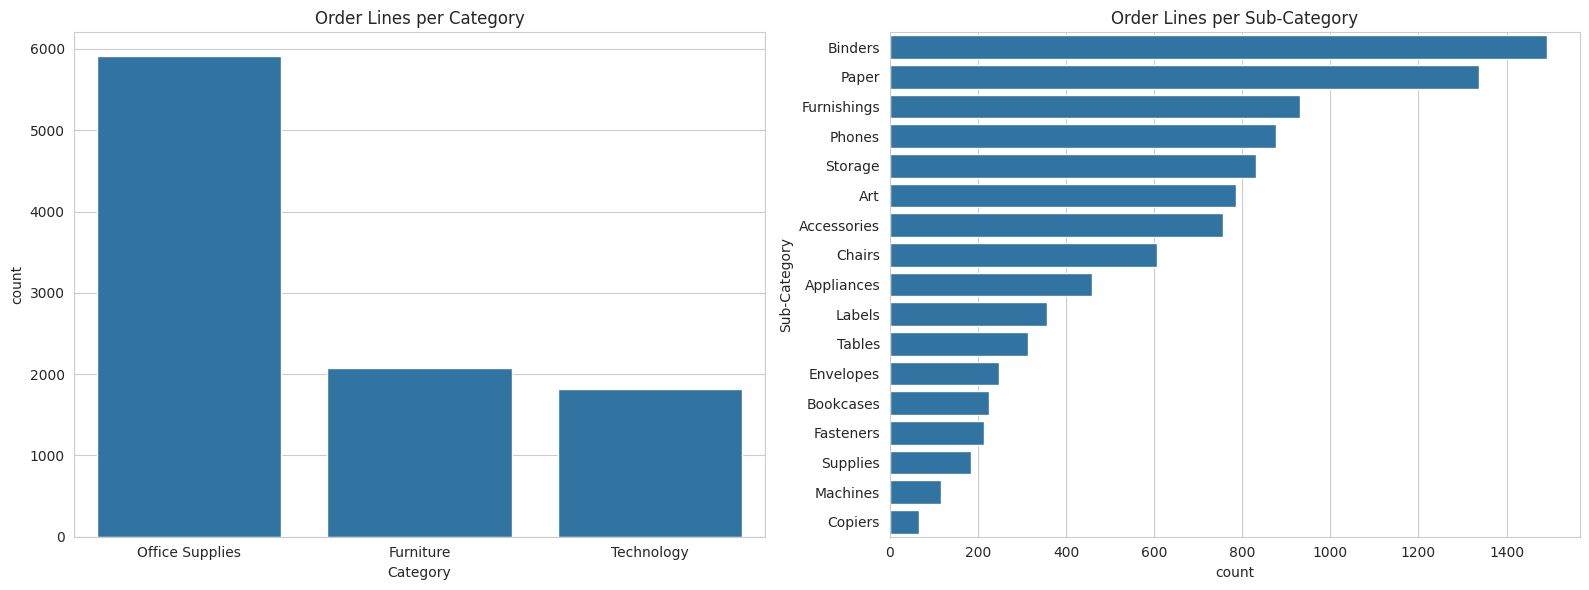

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(x="Category", data=df, order=df["Category"].value_counts().index, ax=axes[0])
axes[0].set_title("Order Lines per Category")

sns.countplot(y="Sub-Category", data=df, order=df["Sub-Category"].value_counts().index, ax=axes[1])
axes[1].set_title("Order Lines per Sub-Category")

plt.tight_layout()
plt.show()

Office Supplies make up about 60% of all order lines, led by Binders and Paper, which are cheap items bought frequently. Technology and Furniture have far fewer lines. Copiers and Machines are the rarest sub-categories with fewer than 120 lines each.

### 6.3 Orders by Segment, Ship Mode and Region

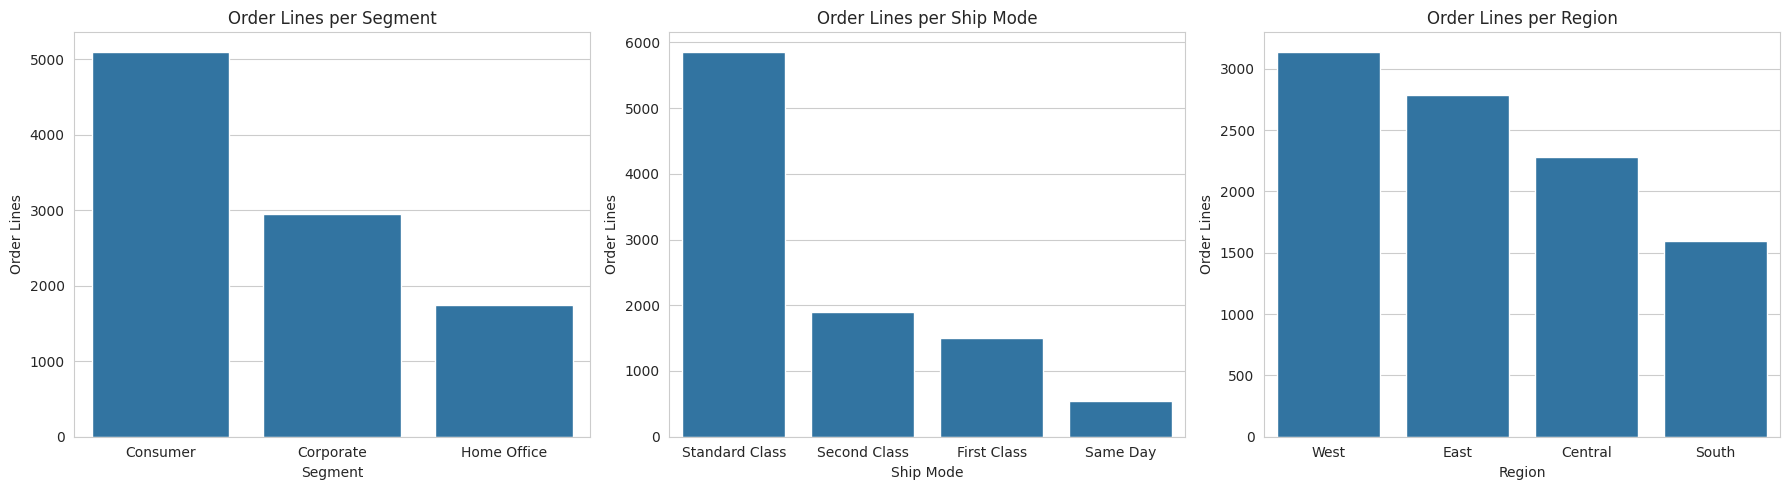

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ["Segment", "Ship Mode", "Region"]):
    sns.countplot(x=col, data=df, order=df[col].value_counts().index, ax=ax)
    ax.set_title(f"Order Lines per {col}")
    ax.set_ylabel("Order Lines")

plt.tight_layout()
plt.show()

Consumers place about half of all order lines, followed by Corporate and Home Office customers. Standard Class is by far the most used shipping mode (about 60%), while Same Day is rare. The West and East regions generate more orders than the Central and South regions.

### 6.4 Shipping days

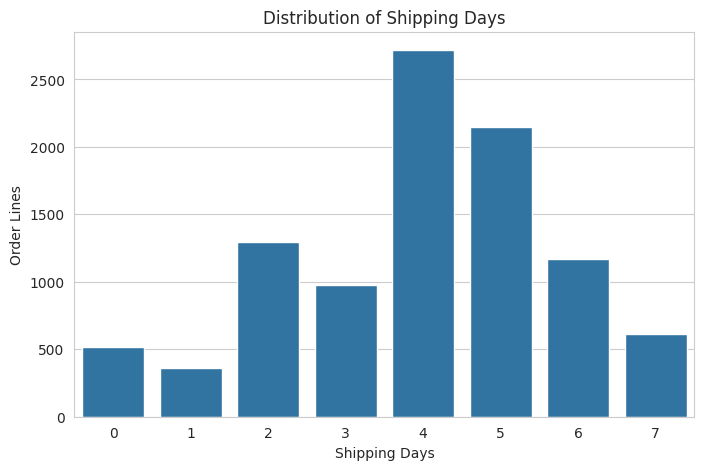

In [22]:
plt.figure(figsize=(8, 5))
sns.countplot(x="Shipping Days", data=df)
plt.title("Distribution of Shipping Days")
plt.ylabel("Order Lines")
plt.show()

Most orders ship within 4 to 5 days, which corresponds to Standard Class. The small group at 0 days is Same Day shipping. Nothing takes more than a week, confirming the date correction made earlier.

## 7. Bivariate Analysis

### 7.1 Sales by Category: total and average

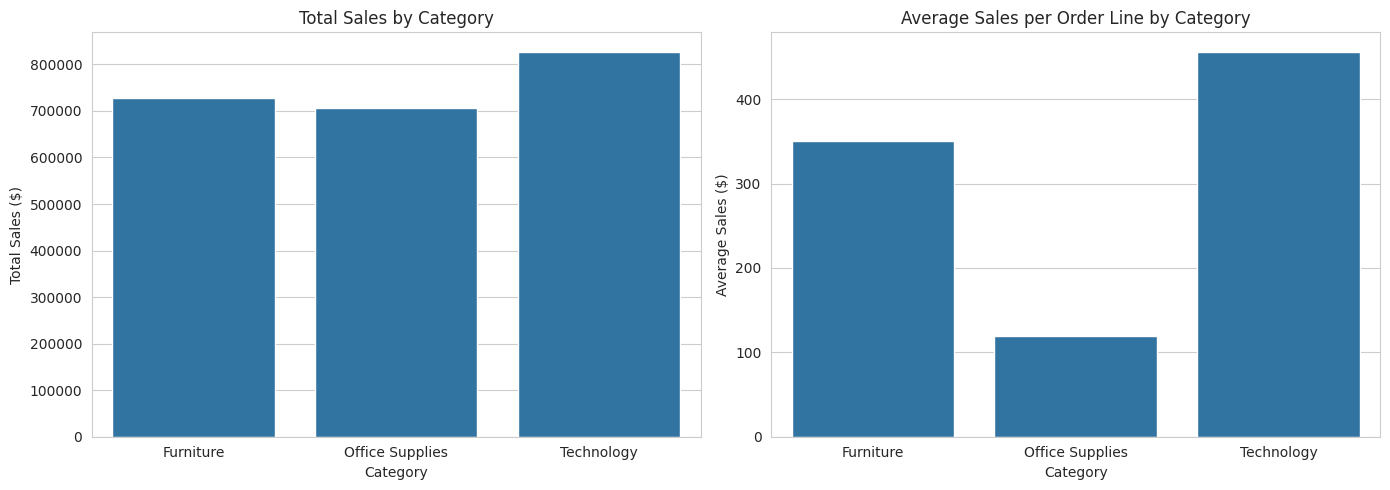

,Total Sales,Average Sales,Median Sales,Order Lines
Category,,,,
Furniture,728658.58,350.65,182.61,2078
Office Supplies,705422.33,119.38,27.36,5909
Technology,827455.87,456.40,167.94,1813


In [23]:
category_stats = df.groupby("Category")["Sales"].agg(["sum", "mean", "median", "count"]).round(2)
category_stats.columns = ["Total Sales", "Average Sales", "Median Sales", "Order Lines"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=category_stats.index, y=category_stats["Total Sales"], ax=axes[0])
axes[0].set_title("Total Sales by Category")
axes[0].set_ylabel("Total Sales ($)")

sns.barplot(x=category_stats.index, y=category_stats["Average Sales"], ax=axes[1])
axes[1].set_title("Average Sales per Order Line by Category")
axes[1].set_ylabel("Average Sales ($)")

plt.tight_layout()
plt.show()

category_stats

Although Office Supplies has almost three times as many order lines as Technology, the three categories generate similar total sales (roughly \$705K to \$827K). This is because a typical Technology line is worth about \$456 and a Furniture line about \$351, while an Office Supplies line is worth only about \$119. Category is therefore a strong predictor of the sales value of a single line.

### 7.2 Sales by Sub-Category

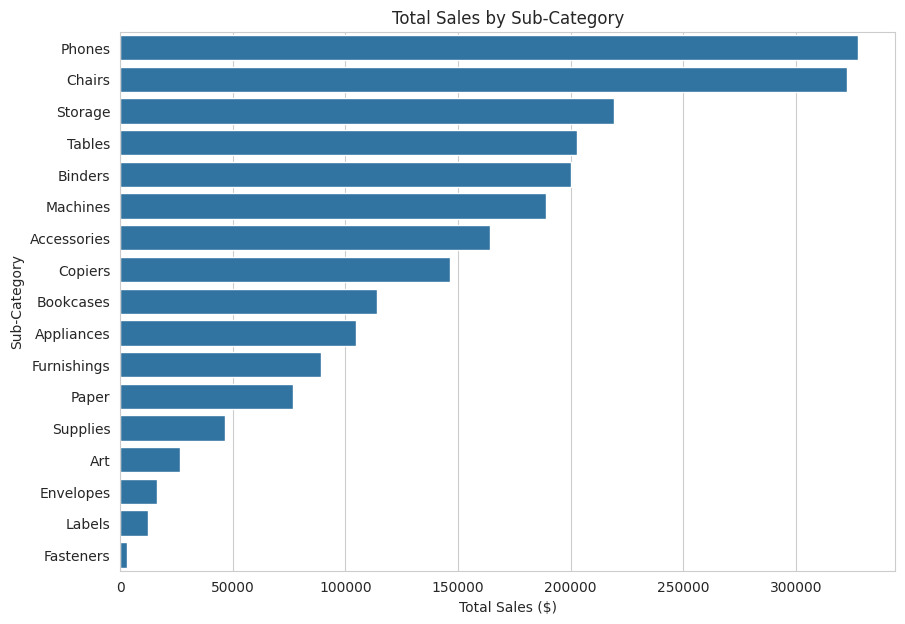

In [24]:
subcat_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=subcat_sales.values, y=subcat_sales.index)
plt.title("Total Sales by Sub-Category")
plt.xlabel("Total Sales ($)")
plt.show()

Phones and Chairs are the two largest sub-categories by revenue, each above \$320K, followed by Storage, Tables, and Binders. Fasteners, Labels, and Envelopes contribute almost nothing. Binders is interesting: it is the most frequently ordered sub-category but only fifth in revenue, again showing the difference between order volume and order value.

### 7.3 Sales distribution by Category (log scale)

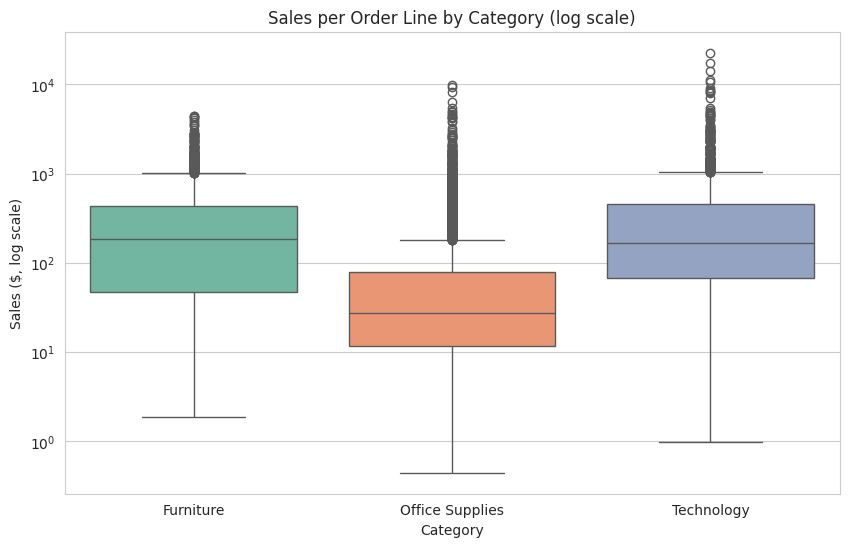

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Category", y="Sales", hue="Category", data=df, palette="Set2", legend=False)
plt.yscale("log")
plt.title("Sales per Order Line by Category (log scale)")
plt.ylabel("Sales ($, log scale)")
plt.show()

On a log scale the difference between categories is clear: the whole Office Supplies box sits below the Furniture and Technology boxes. Technology also has the widest spread, containing both cheap accessories and the most expensive machines in the dataset.

### 7.4 Sales by Region and Segment

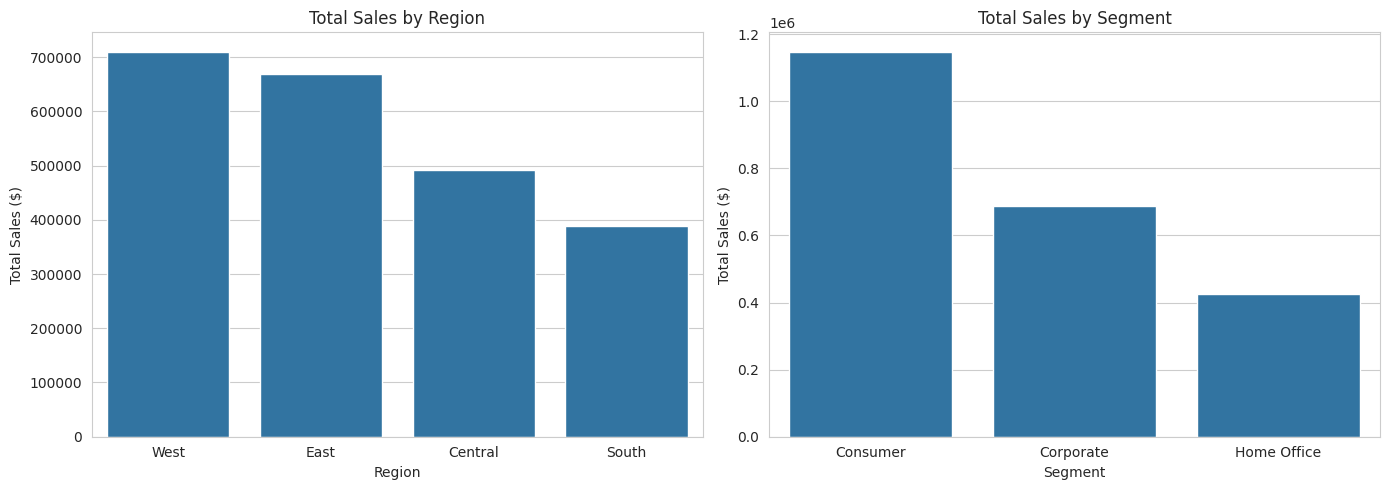

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values, ax=axes[0])
axes[0].set_title("Total Sales by Region")
axes[0].set_ylabel("Total Sales ($)")

segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
sns.barplot(x=segment_sales.index, y=segment_sales.values, ax=axes[1])
axes[1].set_title("Total Sales by Segment")
axes[1].set_ylabel("Total Sales ($)")

plt.tight_layout()
plt.show()

The West (\$710K) and East (\$670K) regions generate the most revenue, while the South (\$389K) is the weakest market. Consumers produce about half of all revenue (\$1.15M), in line with their share of order lines, so the average order value does not differ much between segments.

### 7.5 Top 10 states and top 10 customers

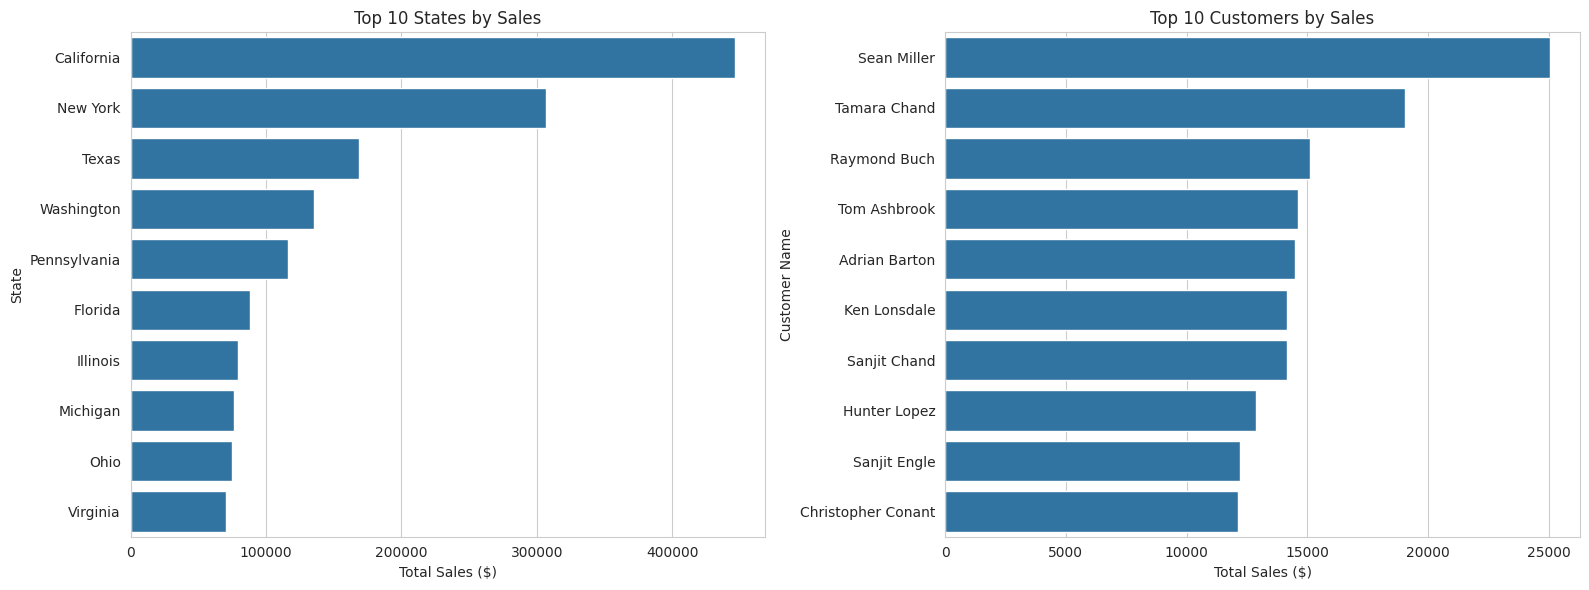

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=state_sales.values, y=state_sales.index, ax=axes[0])
axes[0].set_title("Top 10 States by Sales")
axes[0].set_xlabel("Total Sales ($)")

customer_sales = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
sns.barplot(x=customer_sales.values, y=customer_sales.index, ax=axes[1])
axes[1].set_title("Top 10 Customers by Sales")
axes[1].set_xlabel("Total Sales ($)")

plt.tight_layout()
plt.show()

California (about \$446K) and New York (about \$306K) dominate, together making up roughly a third of all sales; Texas is a distant third. Sales are spread across many customers: the top customer (Sean Miller, about \$25K) accounts for only about 1% of total revenue, so no single customer drives the business.

### 7.6 Sales by Category and Region

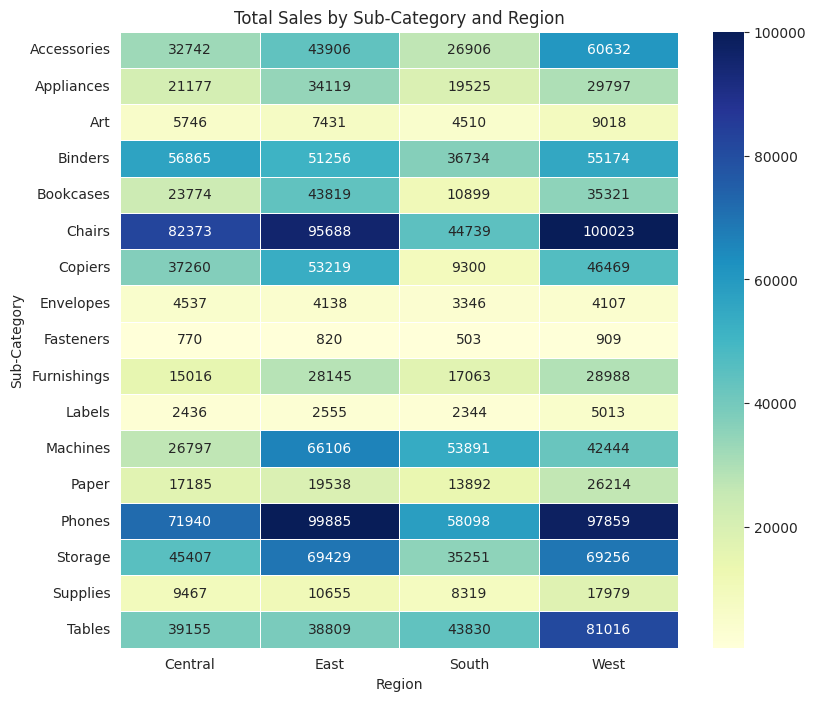

In [28]:
pivot = df.pivot_table(values="Sales", index="Sub-Category", columns="Region", aggfunc="sum")

plt.figure(figsize=(9, 8))
sns.heatmap(pivot, cmap="YlGnBu", annot=True, fmt=".0f", linewidths=0.5)
plt.title("Total Sales by Sub-Category and Region")
plt.show()

The heatmap confirms that Phones and Chairs lead in every region, and that the West is the strongest region for almost every sub-category. The South is consistently the smallest market, so region and sub-category act mostly independently rather than through special combinations.

### 7.7 Ship Mode and Sales

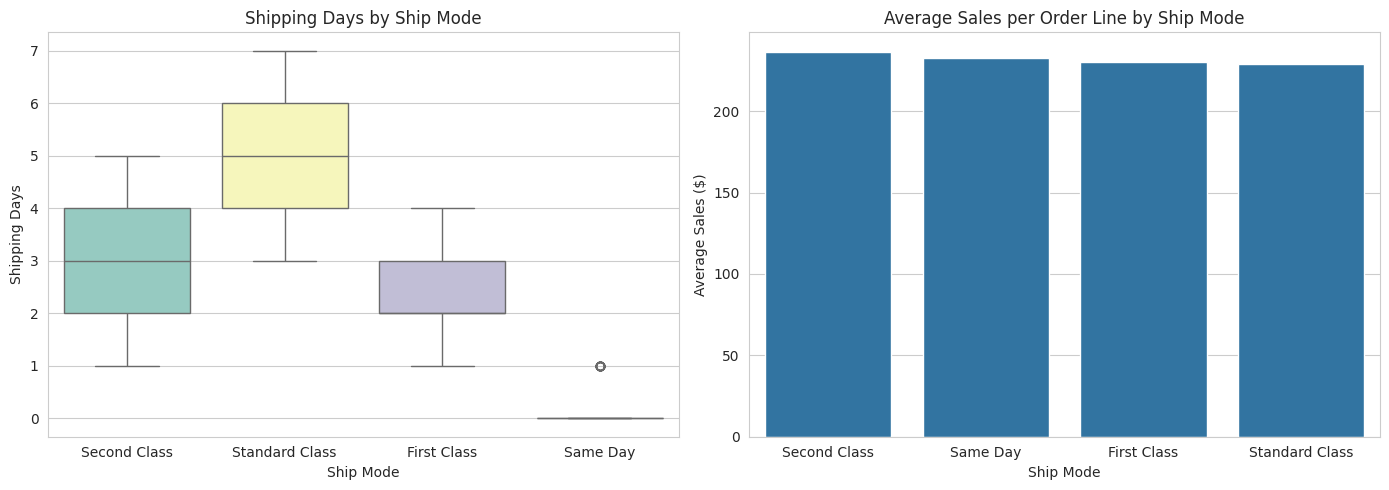

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x="Ship Mode", y="Shipping Days", hue="Ship Mode", data=df, palette="Set3", legend=False, ax=axes[0])
axes[0].set_title("Shipping Days by Ship Mode")

shipmode_avg = df.groupby("Ship Mode")["Sales"].mean().sort_values(ascending=False)
sns.barplot(x=shipmode_avg.index, y=shipmode_avg.values, ax=axes[1])
axes[1].set_title("Average Sales per Order Line by Ship Mode")
axes[1].set_ylabel("Average Sales ($)")

plt.tight_layout()
plt.show()

Shipping days are tightly linked to the shipping mode, as expected. The average sales value per line is similar across shipping modes, so customers do not choose faster shipping for more expensive items. Ship Mode is therefore unlikely to be a useful predictor of Sales.

### 7.8 Order size vs order value

The dataset has one row per product line, so a single order can span several rows. Grouping by `Order ID` gives two new numerical variables per order: how many lines it contains and its total value.

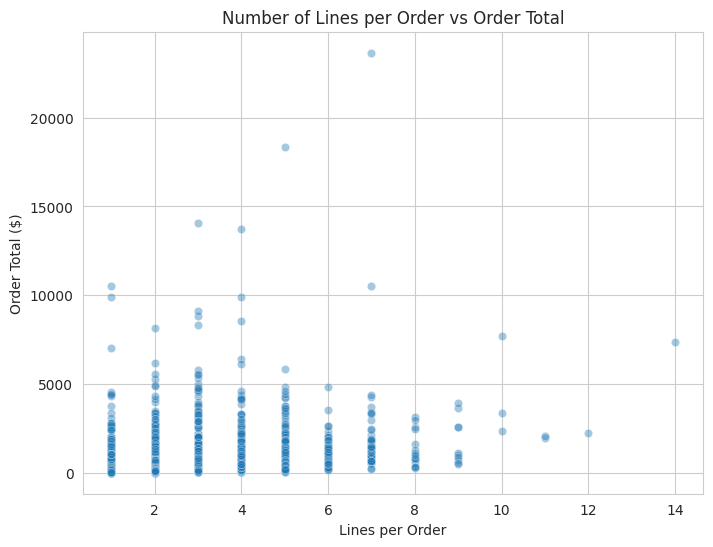

,Lines,Order_Total
count,4922.00,4922.00
mean,1.99,459.48
std,1.41,958.67
min,1.00,0.56
25%,1.00,37.27
50%,1.00,151.88
75%,2.00,513.51
max,14.00,23661.23


In [30]:
orders = df.groupby("Order ID").agg(Lines=("Sales", "size"), Order_Total=("Sales", "sum")).reset_index()

plt.figure(figsize=(8, 6))
sns.scatterplot(x="Lines", y="Order_Total", data=orders, alpha=0.4)
plt.title("Number of Lines per Order vs Order Total")
plt.xlabel("Lines per Order")
plt.ylabel("Order Total ($)")
plt.show()

orders.describe().round(2)

Most orders contain 1 to 3 lines and are worth a few hundred dollars. Order totals do grow with the number of lines, but the spread at each order size is huge: some one-line orders are worth thousands of dollars because they contain a single expensive machine. The number of items is therefore a weak indicator of order value compared with what the items are.

### 7.9 Correlation between numerical columns

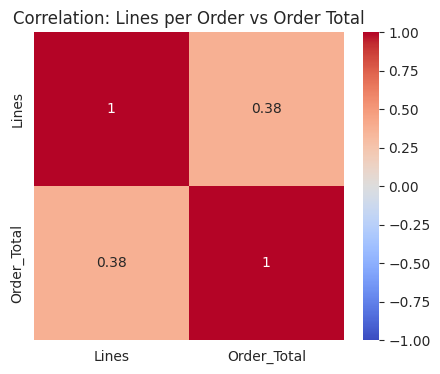

Correlation between Sales and Shipping Days: -0.006


In [31]:
plt.figure(figsize=(5, 4))
sns.heatmap(orders[["Lines", "Order_Total"]].corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation: Lines per Order vs Order Total")
plt.show()

print("Correlation between Sales and Shipping Days:", round(df["Sales"].corr(df["Shipping Days"]), 3))

The correlation between the number of lines and the order total is positive but moderate, and the correlation between Sales and Shipping Days is essentially zero. The dataset has almost no numerical predictors, which confirms that the predictive power for Sales lies in the categorical columns (Category, Sub-Category, Region, State), which will need to be encoded before modelling.

## 8. Time-Based Analysis

### 8.1 Monthly sales trend

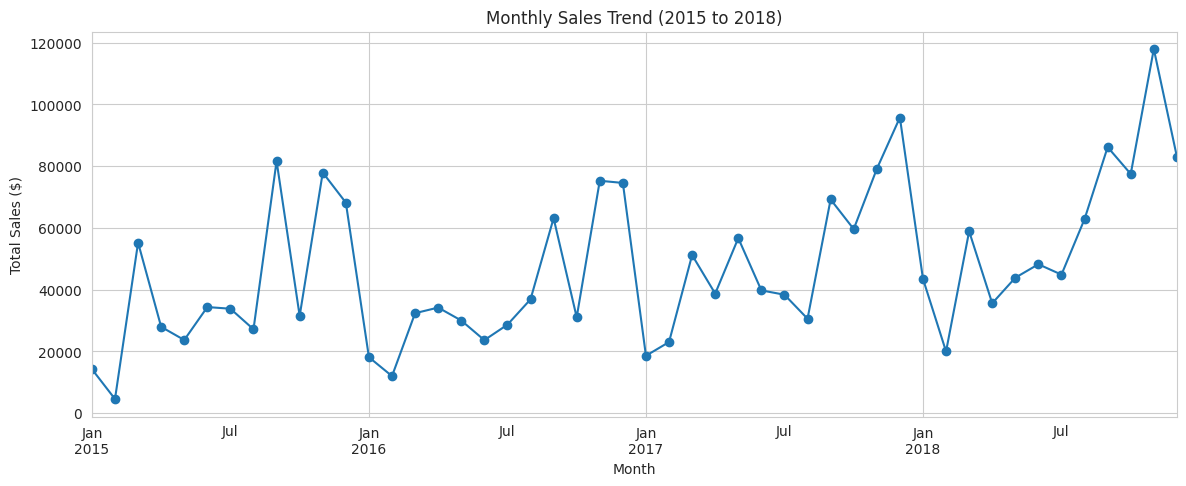

In [32]:
monthly_sales = df.groupby("Order Month")["Sales"].sum()

plt.figure(figsize=(14, 5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend (2015 to 2018)")
plt.ylabel("Total Sales ($)")
plt.xlabel("Month")
plt.show()

Monthly sales show a clear repeating pattern: a low in the first months of each year and peaks in the last quarter. On top of the seasonality there is a gradual upward trend, with the peaks in 2017 and 2018 higher than those in 2015 and 2016.

### 8.2 Sales by year

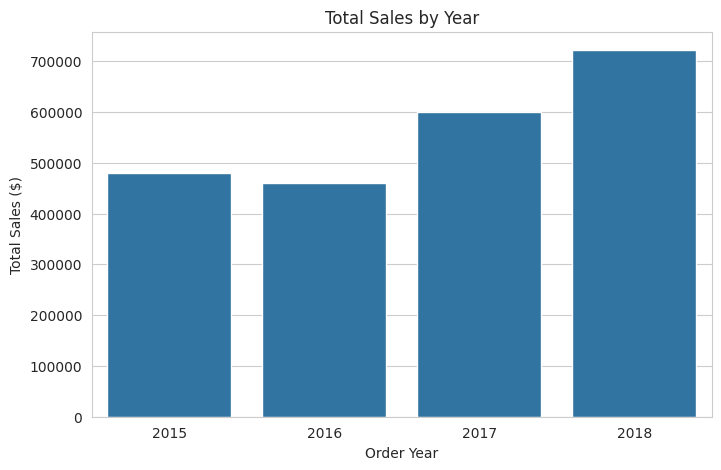

,Total Sales,Order Lines,Average Sales
Order Year,,,
2015,479856.21,1953,245.70
2016,459436.01,2055,223.57
2017,600192.55,2534,236.86
2018,722052.02,3258,221.62


In [33]:
yearly = df.groupby("Order Year")["Sales"].agg(["sum", "count", "mean"]).round(2)
yearly.columns = ["Total Sales", "Order Lines", "Average Sales"]

plt.figure(figsize=(8, 5))
sns.barplot(x=yearly.index, y=yearly["Total Sales"])
plt.title("Total Sales by Year")
plt.ylabel("Total Sales ($)")
plt.show()

yearly

Apart from a small dip in 2016, total sales grow every year and reach about \$722K in 2018, 50% above 2015. The growth comes from the number of order lines (1,953 in 2015 to 3,258 in 2018) while the average value per line stays roughly stable around \$220 to \$245, so the business is growing in volume rather than in price.

### 8.3 Seasonality by month of the year

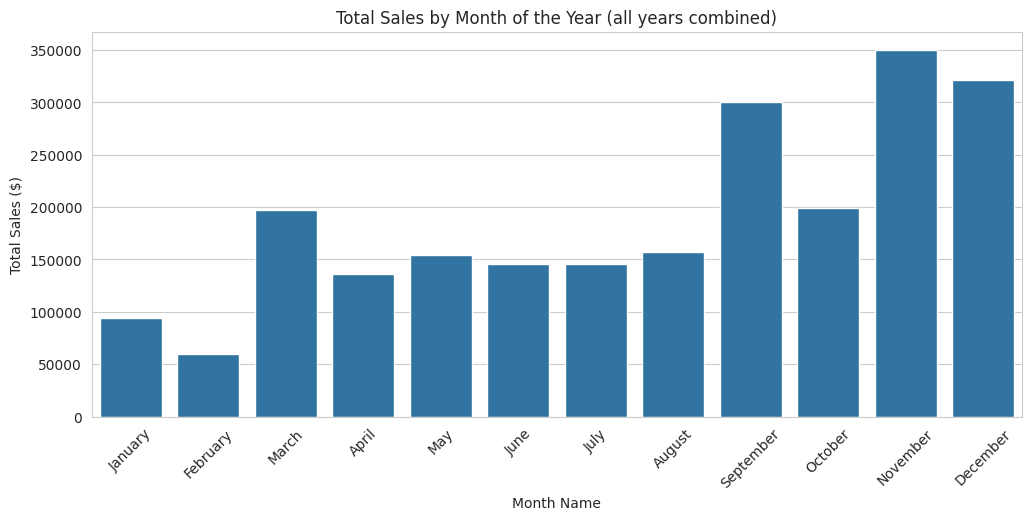

In [34]:
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
season = df.groupby("Month Name")["Sales"].sum().reindex(month_order)

plt.figure(figsize=(12, 5))
sns.barplot(x=season.index, y=season.values)
plt.title("Total Sales by Month of the Year (all years combined)")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.show()

Combining all years, November (about \$350K) and December (about \$321K) are the strongest months and February (about \$59K) is the weakest, roughly six times smaller. September also stands out as the third strongest month, matching the back-to-school and end-of-quarter period. The order month is therefore a meaningful feature for any forecasting model.

### 8.4 Monthly sales by Category

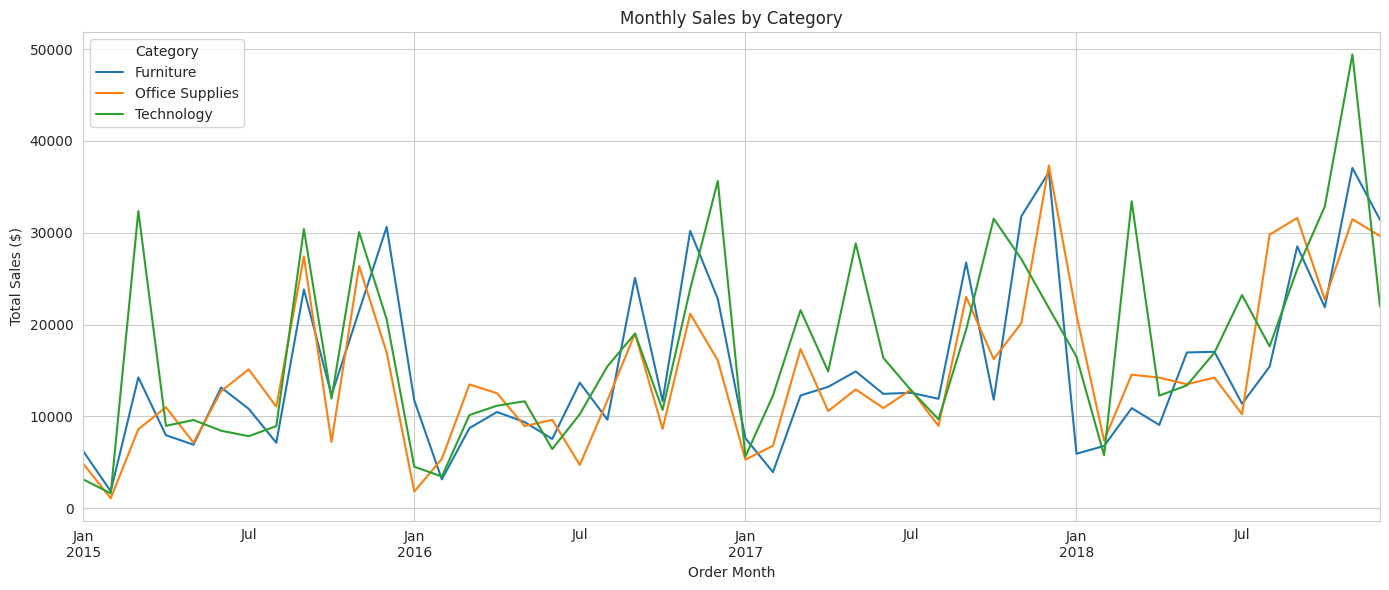

In [35]:
monthly_category = df.groupby(["Order Month", "Category"])["Sales"].sum().unstack()

plt.figure(figsize=(14, 6))
monthly_category.plot(ax=plt.gca())
plt.title("Monthly Sales by Category")
plt.ylabel("Total Sales ($)")
plt.legend(title="Category")
plt.tight_layout()
plt.show()

All three categories follow the same seasonal rhythm, but Technology has the sharpest spikes because a single expensive machine can move a month's total. Office Supplies is the most stable line, reflecting its many small, regular purchases.

## 9. Summary of Findings

**Data quality**
- The date columns were corrupted by Excel: 40% of the values had day and month swapped and 60% were left as text. They were repaired and verified through shipping times, which now match the shipping modes exactly.
- 11 missing postal codes (all Burlington, VT) were filled; there were no duplicates. `Row ID` and `Country` were dropped because they carry no information.

**Target variable**
- `Sales` is heavily right-skewed (median \$54, mean \$231, max \$22,638). A log transformation makes it approximately normal, so a regression model should predict log(Sales).

**Categories**
- Office Supplies dominate in volume but Technology and Furniture dominate in value; the three categories end up with similar total sales.
- Phones and Chairs are the top revenue sub-categories. Binders are ordered most often but rank only fifth in revenue.
- The West and East regions and the states of California and New York generate most of the revenue. Consumers produce half of all sales.

**Relationships**
- Shipping days depend only on Ship Mode, and neither is related to Sales. The useful predictors are the categorical columns, especially Sub-Category, Category, Region, and State.

**Time**
- Sales grow from 2015 to 2018 (with a small dip in 2016), driven by more orders rather than higher prices, with strong seasonality peaking in November and December.

**Implications for modelling**
- Encode Sub-Category, Category, Region, State, and Segment; include the order month; train on log(Sales); and expect a small number of very large orders to remain hard to predict.